# 04_01 데이터 분석 정리: pandas와 시각화

이번 실습에서는 약 2,000건의 온라인 판매 데이터를 직접 만들고, `pandas`로 데이터를 정리한 뒤 `matplotlib`와 `seaborn`으로 패턴을 확인합니다.

학습 목표:

- 재현 가능한 가상 데이터를 `DataFrame`으로 만들기
- 날짜와 숫자 열을 이용해 파생변수와 집계표 만들기
- 질문에 맞는 시각화 선택하기
- 그래프에서 발견한 내용을 숫자로 다시 확인하기

## 1. 실습 데이터 만들기

실제 분석에서는 먼저 데이터의 행과 열, 자료형, 결측치를 확인합니다. 여기서는 연습을 위해 실행할 때마다 같은 결과가 나오는 가상 판매 데이터를 생성합니다.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from pathlib import Path
import koreanize_matplotlib

sns.set_theme(style='whitegrid')
font_path = Path(koreanize_matplotlib.__file__).parent / 'fonts' / 'NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 난수 시드를 고정하면 실행할 때마다 같은 2,000건이 만들어집니다.
rng = np.random.default_rng(42)
row_count = 2000

dates = pd.date_range('2024-01-01', '2024-12-31', periods=row_count)
regions = rng.choice(['수도권', '영남권', '호남권', '충청권'], row_count, p=[0.38, 0.27, 0.18, 0.17])
categories = rng.choice(['전자기기', '생활용품', '식품', '패션', '스포츠'], row_count)
channels = rng.choice(['온라인', '모바일앱', '제휴몰'], row_count, p=[0.45, 0.35, 0.20])

category_price = {'전자기기': 180000, '생활용품': 45000, '식품': 28000, '패션': 70000, '스포츠': 90000}
unit_price = np.array([category_price[category] for category in categories]) * rng.uniform(0.75, 1.25, row_count)
quantity = rng.integers(1, 6, row_count)
discount_rate = rng.choice([0, 0.05, 0.10, 0.15, 0.20], row_count, p=[0.20, 0.25, 0.30, 0.20, 0.05])
advertising_cost = rng.gamma(shape=2.5, scale=18000, size=row_count)

audit_df = pd.DataFrame({
    '주문일': dates,
    '지역': regions,
    '카테고리': categories,
    '판매채널': channels,
    '수량': quantity,
    '단가': unit_price.round(0),
    '할인율': discount_rate,
    '광고비': advertising_cost.round(0),
})
audit_df['매출액'] = audit_df['수량'] * audit_df['단가']
audit_df['순매출'] = audit_df['매출액'] * (1 - audit_df['할인율'])
sales_df = audit_df

print(f'데이터 크기: {sales_df.shape[0]:,}행 x {sales_df.shape[1]}열')
sales_df.head()

데이터 크기: 2,000행 x 10열


,주문일,지역,카테고리,판매채널,수량,단가,할인율,광고비,매출액,순매출
0,2024-01-01 00:00:00.000000,호남권,생활용품,제휴몰,2,38658.0,0.10,7357.0,77316.0,69584.4
1,2024-01-01 04:22:55.887943,영남권,스포츠,모바일앱,4,97332.0,0.15,79479.0,389328.0,330928.8
2,2024-01-01 08:45:51.775887,충청권,전자기기,온라인,1,204018.0,0.05,54506.0,204018.0,193817.1
3,2024-01-01 13:08:47.663831,호남권,식품,모바일앱,5,23333.0,0.00,45767.0,116665.0,116665.0
4,2024-01-01 17:31:43.551775,수도권,스포츠,온라인,3,69474.0,0.15,57927.0,208422.0,177158.7


## 2. pandas로 데이터 구조와 품질 확인

`info()`, `describe()`, `isna()`는 분석 전에 자주 사용하는 기본 점검 도구입니다. 데이터가 예상한 형태인지 먼저 확인해야 그래프도 올바르게 해석할 수 있습니다.

In [8]:
# 날짜 열을 datetime 자료형으로 바꾸고 분석에 필요한 정보를 확인합니다.
sales_df['주문일'] = pd.to_datetime(sales_df['주문일'])

print('자료형과 메모리 사용량')
sales_df.info()

print('\n기초 통계')
display(sales_df[['수량', '단가', '할인율', '광고비', '매출액', '순매출']].describe().round(1))

print('\n열별 결측치 개수')
print(sales_df.isna().sum())

# 날짜에서 월을 추출하면 시간 흐름에 따른 집계를 쉽게 만들 수 있습니다.
sales_df['월'] = sales_df['주문일'].dt.month
monthly_summary = sales_df.groupby('월', as_index=False).agg(
    주문건수=('주문일', 'size'),
    총매출=('매출액', 'sum'),
    순매출=('순매출', 'sum'),
    평균주문금액=('순매출', 'mean')
)
region_summary = sales_df.groupby('지역', as_index=False).agg(
    주문건수=('주문일', 'size'),
    순매출=('순매출', 'sum'),
    평균주문금액=('순매출', 'mean')
).sort_values('순매출', ascending=False)
category_summary = sales_df.groupby('카테고리', as_index=False).agg(
    주문건수=('주문일', 'size'),
    순매출=('순매출', 'sum')
).sort_values('순매출', ascending=False)

print('\n지역별 요약')
display(region_summary.round(0))
print('월별 요약')
display(monthly_summary.round(0))

자료형과 메모리 사용량
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   주문일     2000 non-null   datetime64[us]
 1   지역      2000 non-null   str           
 2   카테고리    2000 non-null   str           
 3   판매채널    2000 non-null   str           
 4   수량      2000 non-null   int64         
 5   단가      2000 non-null   float64       
 6   할인율     2000 non-null   float64       
 7   광고비     2000 non-null   float64       
 8   매출액     2000 non-null   float64       
 9   순매출     2000 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(3)
memory usage: 156.4 KB

기초 통계


,수량,단가,할인율,광고비,매출액,순매출
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,3.0,81638.4,0.1,44674.1,244110.5,224322.3
std,1.4,54168.9,0.1,29155.9,212399.8,197375.4
min,1.0,21076.0,0.0,1217.0,21118.0,18184.0
25%,2.0,38478.0,0.0,24031.2,98052.0,88982.4
50%,3.0,67494.5,0.1,38556.5,170220.0,156140.0
75%,4.0,101649.0,0.1,58287.5,326251.5,298871.5
max,5.0,224954.0,0.2,284785.0,1120780.0,1106915.0



열별 결측치 개수
주문일     0
지역      0
카테고리    0
판매채널    0
수량      0
단가      0
할인율     0
광고비     0
매출액     0
순매출     0
dtype: int64

지역별 요약


,지역,주문건수,순매출,평균주문금액
0,수도권,751,164572449.0,219138.0
1,영남권,542,123475338.0,227814.0
3,호남권,351,84172230.0,239807.0
2,충청권,356,76424617.0,214676.0


월별 요약


,월,주문건수,총매출,순매출,평균주문금액
0,1,170,39582879.0,36244872.0,213205.0
1,2,159,38137210.0,35293756.0,221973.0
2,3,170,39346921.0,35899936.0,211176.0
3,4,164,39240861.0,36199370.0,220728.0
4,5,170,42105164.0,38552611.0,226780.0
5,6,164,42184246.0,38903140.0,237214.0
6,7,170,39305408.0,35838661.0,210816.0
7,8,170,42571768.0,39082103.0,229895.0
8,9,164,39061800.0,35803378.0,218313.0
9,10,170,41283327.0,38092420.0,224073.0


## 3. 범주와 시간에 따른 매출 비교

범주별 크기를 비교할 때는 막대 그래프를, 시간의 흐름을 볼 때는 선 그래프를 사용합니다. 먼저 `groupby()` 결과를 그래프로 표현해 보겠습니다.

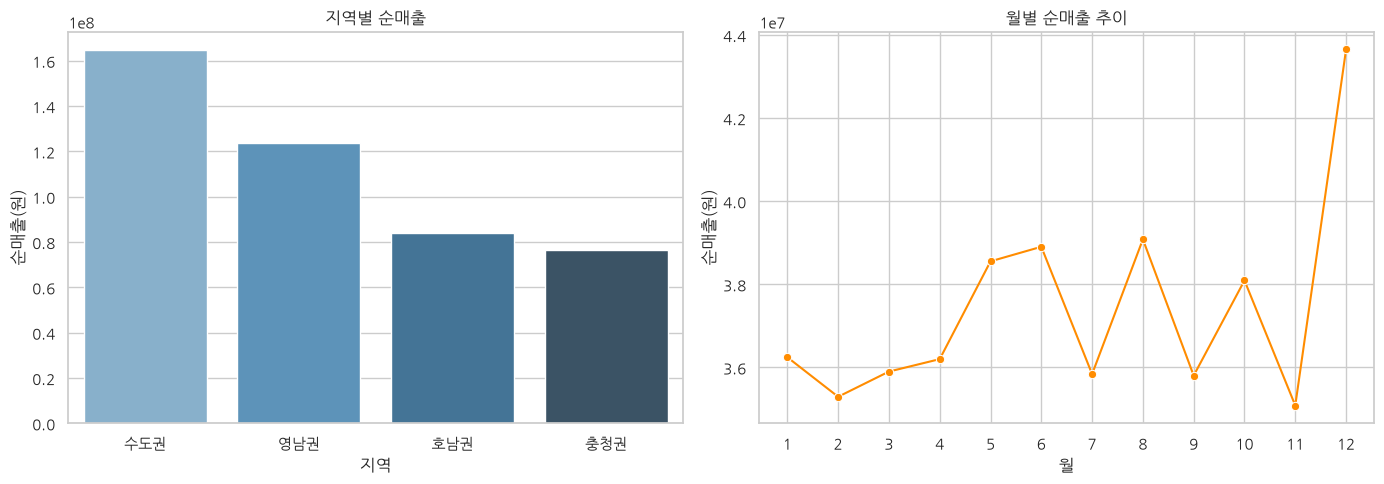

순매출이 가장 높은 지역: 수도권
순매출이 가장 높은 월: 12월


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 지역별 순매출: 지역 간 규모 비교
sns.barplot(data=region_summary, x='지역', y='순매출', hue='지역', legend=False, palette='Blues_d', ax=axes[0])
axes[0].set_title('지역별 순매출')
axes[0].set_xlabel('지역')
axes[0].set_ylabel('순매출(원)')

# 월별 순매출: 1월부터 12월까지의 흐름 확인
sns.lineplot(data=monthly_summary, x='월', y='순매출', marker='o', color='darkorange', ax=axes[1])
axes[1].set_title('월별 순매출 추이')
axes[1].set_xlabel('월')
axes[1].set_ylabel('순매출(원)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"순매출이 가장 높은 지역: {region_summary.iloc[0]['지역']}")
print(f"순매출이 가장 높은 월: {monthly_summary.loc[monthly_summary['순매출'].idxmax(), '월']}월")

## 4. 관계와 분포 살펴보기

광고비와 순매출의 관계는 산점도로, 값이 어느 구간에 몰려 있는지는 히스토그램으로 확인합니다. 박스플롯은 지역별 중앙값과 퍼짐, 이상치를 한 번에 비교할 때 유용합니다.

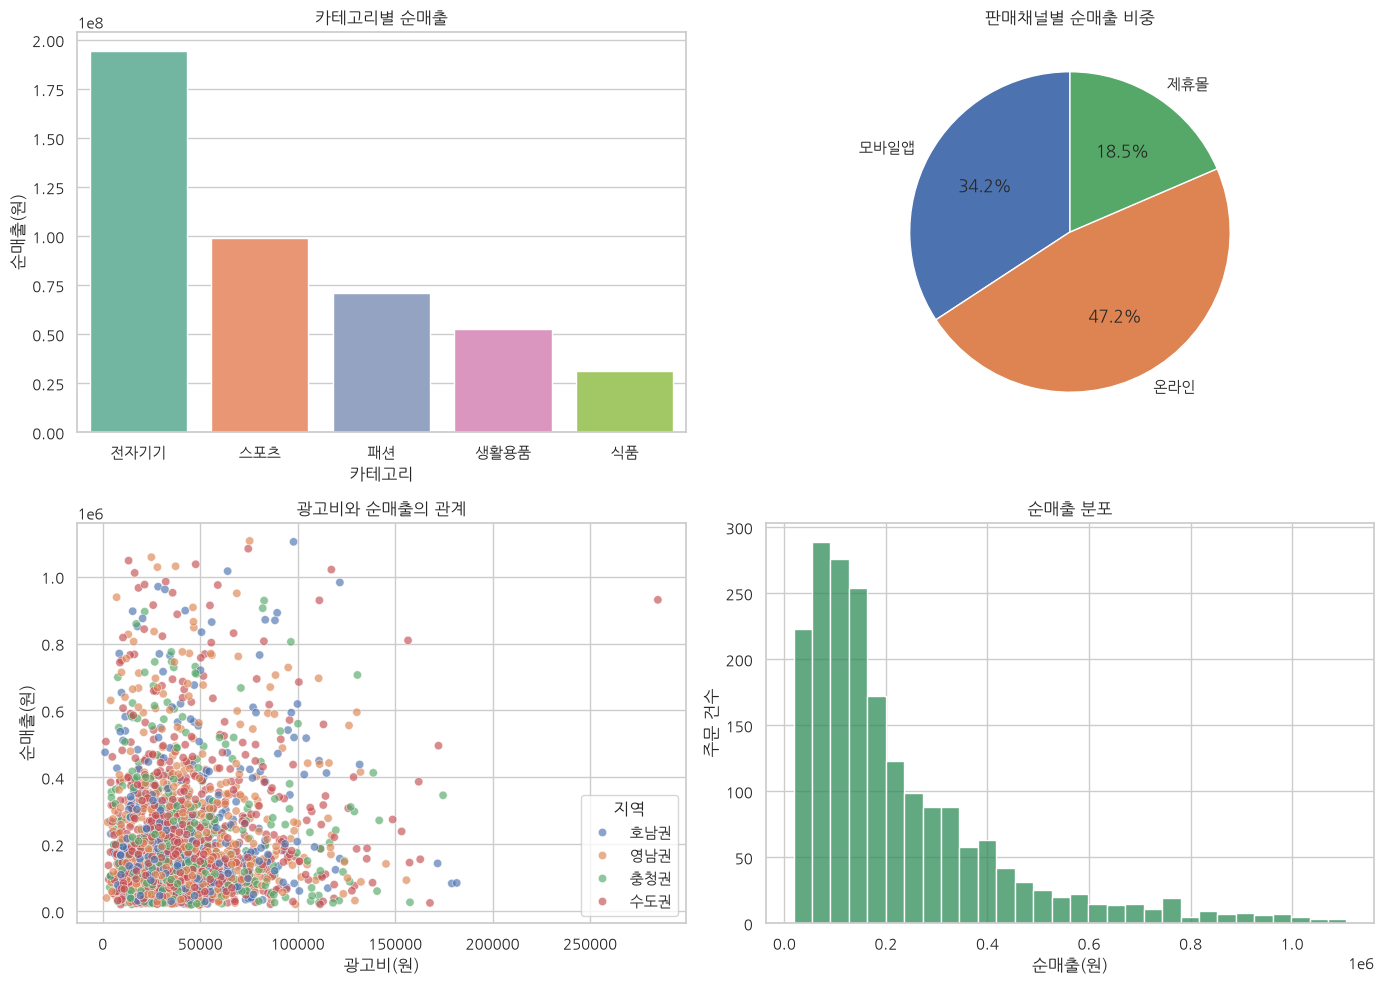

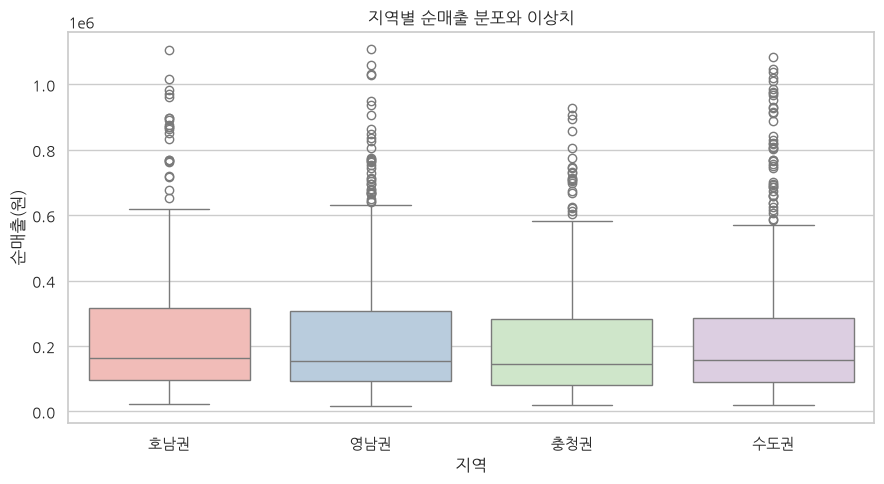

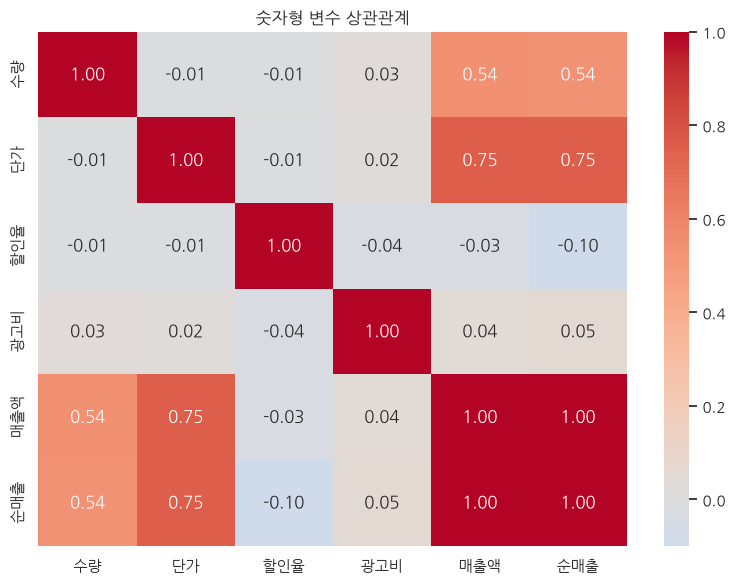

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 카테고리별 순매출 비교
sns.barplot(data=category_summary, x='카테고리', y='순매출', hue='카테고리', legend=False, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('카테고리별 순매출')
axes[0, 0].set_xlabel('카테고리')
axes[0, 0].set_ylabel('순매출(원)')

# 판매채널별 매출 비중
channel_share = sales_df.groupby('판매채널')['순매출'].sum()
axes[0, 1].pie(channel_share, labels=channel_share.index, autopct='%.1f%%', startangle=90)
axes[0, 1].set_title('판매채널별 순매출 비중')

# 광고비와 순매출의 관계
sns.scatterplot(data=sales_df, x='광고비', y='순매출', hue='지역', alpha=0.65, ax=axes[1, 0])
axes[1, 0].set_title('광고비와 순매출의 관계')
axes[1, 0].set_xlabel('광고비(원)')
axes[1, 0].set_ylabel('순매출(원)')

# 순매출 분포와 지역별 분포
sns.histplot(data=sales_df, x='순매출', bins=30, color='seagreen', ax=axes[1, 1])
axes[1, 1].set_title('순매출 분포')
axes[1, 1].set_xlabel('순매출(원)')
axes[1, 1].set_ylabel('주문 건수')

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=sales_df, x='지역', y='순매출', hue='지역', legend=False, palette='Pastel1')
plt.title('지역별 순매출 분포와 이상치')
plt.xlabel('지역')
plt.ylabel('순매출(원)')
plt.tight_layout()
plt.show()

# 숫자형 변수 사이의 선형 관계를 확인합니다.
correlation_columns = ['수량', '단가', '할인율', '광고비', '매출액', '순매출']
plt.figure(figsize=(8, 6))
sns.heatmap(sales_df[correlation_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('숫자형 변수 상관관계')
plt.tight_layout()
plt.show()

## 5. 분석 질문과 핵심 정리

다음 질문에 그래프와 집계표를 근거로 답해 보세요.

1. 순매출이 가장 높은 지역과 카테고리는 어디인가요?
2. 월별 순매출 추이에서 눈에 띄는 변화가 있나요?
3. 광고비가 높은 주문일수록 순매출도 높다고 말할 수 있나요?
4. 지역별 순매출 분포에서 중앙값과 이상치가 어떻게 다른가요?
5. 판매채널별 매출 비중을 보고 어떤 채널을 우선적으로 관리할 수 있을까요?

핵심 정리:

- `groupby()`와 `agg()`는 범주별 요약표를 만드는 기본 도구입니다.
- 막대 그래프는 범주 비교, 선 그래프는 시간 흐름, 산점도는 두 수치의 관계에 적합합니다.
- 히스토그램과 박스플롯은 분포와 이상치를 확인하는 데 도움이 됩니다.
- 시각화 결과는 평균이나 상관계수 같은 숫자와 함께 확인해야 더 정확하게 해석할 수 있습니다.